In [1]:
from dataclasses import dataclass
from typing import Optional, Tuple, Dict, Any, List

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.optimize import brentq
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
"""
Reproduce Fig.1-like dynamics for:
(2017) Intrinsically-generated fluctuating activity in excitatory-inhibitory networks

Model:
    x_dot = -x + J_ij * phi(x) + I
Threshold-linear with offset gamma (paper Eq. 22):
    phi(x) = 0              if x < -gamma
           = x + gamma      if -gamma <= x <= phi_max - gamma
           = phi_max        if x > phi_max - gamma

Fig.1 defaults:
    g=4.5, C=100, N=2000, phi_max=inf  (no saturation)
"""

'\nReproduce Fig.1-like dynamics for:\n(2017) Intrinsically-generated fluctuating activity in excitatory-inhibitory networks\n\nModel:\n    x_dot = -x + J_ij * phi(x) + I\nThreshold-linear with offset gamma (paper Eq. 22):\n    phi(x) = 0              if x < -gamma\n           = x + gamma      if -gamma <= x <= phi_max - gamma\n           = phi_max        if x > phi_max - gamma\n\nFig.1 defaults:\n    g=4.5, C=100, N=2000, phi_max=inf  (no saturation)\n'

In [3]:
# -----------------------------
# Params container (no defaults)
# -----------------------------
@dataclass(frozen=True)
class EIParams:
    N: int
    C: int
    f: float
    g: float
    allow_autapses: bool

    gamma: float
    phi_max: float

    I: float
    dt: float
    T: float

    seed: int


# -----------------------------
# Activation + derivative
# -----------------------------
def phi(x: np.ndarray, gamma: float, phi_max: float) -> np.ndarray:
    y = np.maximum(0.0, x + gamma)
    if np.isfinite(phi_max):
        y = np.minimum(phi_max, y)
    return y


def phi_prime_scalar(x0: float, gamma: float, phi_max: float) -> float:
    if x0 < -gamma:
        return 0.0
    if np.isfinite(phi_max) and x0 > (phi_max - gamma):
        return 0.0
    return 1.0


# -----------------------------
# Homogeneous fixed point
# -----------------------------
def fixed_point_x0(J: float, p: EIParams) -> float:
    CE = int(round(p.f * p.C))
    CI = p.C - CE
    Jeff = J * (CE - p.g * CI)

    # linear regime candidate: phi(x0)=x0+gamma
    if abs(1.0 - Jeff) > 1e-12:
        x0_lin = (Jeff * p.gamma + p.I) / (1.0 - Jeff)
    else:
        # edge case (rare)
        x0_lin = p.I

    if x0_lin >= -p.gamma and (not np.isfinite(p.phi_max) or x0_lin <= (p.phi_max - p.gamma)):
        return x0_lin

    if x0_lin < -p.gamma:
        return p.I  # silent: phi=0 => x0=I
    else:
        return Jeff * p.phi_max + p.I  # saturated: phi=phi_max


# -----------------------------
# Connectivity (fixed indegree)
# -----------------------------
def build_fixed_indegree_connectivity(p: EIParams) -> Tuple[csr_matrix, Dict[str, Any]]:
    rng = np.random.default_rng(p.seed)

    NE = int(round(p.f * p.N))
    NI = p.N - NE
    exc = np.arange(NE)
    inh = np.arange(NE, p.N)

    CE = int(round(p.f * p.C))
    CI = p.C - CE

    rows, cols, data = [], [], []

    for i in range(p.N):
        pre_exc = rng.choice(exc, size=CE, replace=False)
        pre_inh = rng.choice(inh, size=CI, replace=False)

        if not p.allow_autapses:
            if i < NE:
                if i in pre_exc:
                    idx = np.where(pre_exc == i)[0]
                    for k in idx:
                        cand = i
                        while cand == i or cand in pre_exc:
                            cand = rng.choice(exc)
                        pre_exc[k] = cand
            else:
                if i in pre_inh:
                    idx = np.where(pre_inh == i)[0]
                    for k in idx:
                        cand = i
                        while cand == i or cand in pre_inh:
                            cand = rng.choice(inh)
                        pre_inh[k] = cand

        rows.extend([i] * CE)
        cols.extend(pre_exc.tolist())
        data.extend([1.0] * CE)

        rows.extend([i] * CI)
        cols.extend(pre_inh.tolist())
        data.extend([-p.g] * CI)

    W_base = csr_matrix((np.array(data), (np.array(rows), np.array(cols))), shape=(p.N, p.N))
    meta = dict(NE=NE, NI=NI, CE=CE, CI=CI)
    return W_base, meta


# -----------------------------
# Simulation
# -----------------------------
def simulate_rate_network(
    W_base: csr_matrix,
    J: float,
    p: EIParams,
    n_trace: int,
    trace_seed: int,
    x_init: Optional[np.ndarray],
    stop_if_rate_exceeds: Optional[float],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(p.seed + 123)

    if x_init is None:
        x = rng.normal(loc=0.0, scale=0.1, size=p.N)
    else:
        x = x_init.copy()

    steps = int(np.round(p.T / p.dt))
    t = np.arange(steps + 1) * p.dt

    trace_rng = np.random.default_rng(trace_seed)
    trace_ids = trace_rng.choice(p.N, size=n_trace, replace=False)

    traces = np.zeros((steps + 1, n_trace), dtype=float)
    traces[0] = phi(x[trace_ids], p.gamma, p.phi_max)

    W = W_base * J

    for k in range(steps):
        r = phi(x, p.gamma, p.phi_max)
        dx = -x + W.dot(r) + p.I
        x = x + p.dt * dx
        traces[k + 1] = phi(x[trace_ids], p.gamma, p.phi_max)

        if stop_if_rate_exceeds is not None and np.max(traces[k + 1]) > stop_if_rate_exceeds:
            t = t[: k + 2]
            traces = traces[: k + 2]
            break

    return t, traces, trace_ids


# -----------------------------
# Spectrum for inset
# -----------------------------

def compute_spectrum_full(
    W_base: csr_matrix,
    J: float,
    p: EIParams,
) -> Tuple[np.ndarray, float, float]:
    """
    Compute eigenspectrum of the FULL stability matrix:
        S = (J * phi'(x0)) * W_base
    using the full N x N network (no sub-blocks).
    """
    x0 = fixed_point_x0(J, p)
    gain = phi_prime_scalar(x0, p.gamma, p.phi_max)

    # Full dense matrix (can be heavy for large N)
    S = (W_base * (J * gain)).toarray()
    eigvals = np.linalg.eigvals(S)
    return eigvals, x0, gain



def solve_J0(p: EIParams, J_lo: float, J_hi: float) -> float:
    """
    Solve for J0 from:
        phi'(x0(J)) * J * sqrt(CE + g^2 CI) = 1
    using brentq on [J_lo, J_hi].
    """
    CE = int(round(p.f * p.C))
    CI = p.C - CE
    R = np.sqrt(CE + (p.g ** 2) * CI)

    def F(J: float) -> float:
        x0 = fixed_point_x0(J, p)
        gain = phi_prime_scalar(x0, p.gamma, p.phi_max)
        return gain * J * R - 1.0

    return brentq(F, J_lo, J_hi)



# -----------------------------
# Plot figure (Fig.1-like)
# -----------------------------

def plot_fig1_like(
    W_base,
    Js,
    p,
    n_trace,
    trace_seed,
    stop_if_rate_exceeds,
    stability_re_line,
    max_cols=3,
    col_width=4.2,
    row_height=3.2,
):
    n = len(Js)
    ncols = min(max_cols, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(col_width * ncols, row_height * nrows),
        constrained_layout=True
    )
    axes = np.atleast_1d(axes).ravel()

    for i, J in enumerate(Js):
        ax = axes[i]

        t, traces, _ = simulate_rate_network(
            W_base=W_base,
            J=J,
            p=p,
            n_trace=n_trace,
            trace_seed=trace_seed,
            x_init=None,
            stop_if_rate_exceeds=stop_if_rate_exceeds,
        )

        ax.plot(t, traces, linewidth=1.2)
        ax.set_title(f"J = {J:g}", fontsize=11)
        ax.grid(alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if i % ncols == 0:
            ax.set_ylabel(r"Firing rate $\phi(x_i)$")
        else:
            ax.set_ylabel("")
        if i // ncols == nrows - 1:
            ax.set_xlabel("t")
        else:
            ax.set_xlabel("")

        # ---- Inset spectrum (FULL matrix) ----
        eigvals, _, _ = compute_spectrum_full(W_base, J, p)
        iax = inset_axes(ax, width="33%", height="55%", loc="upper left", borderpad=1.0)
        iax.scatter(eigvals.real, eigvals.imag, s=2, alpha=0.25)
        iax.axvline(stability_re_line, color="red", linestyle="--", linewidth=1)
        iax.axhline(0.0, color="k", linewidth=0.5, alpha=0.35)
        iax.axvline(0.0, color="k", linewidth=0.5, alpha=0.35)
        iax.set_xticks([])
        iax.set_yticks([])
        iax.set_aspect("equal", "box")

    for j in range(n, nrows * ncols):
        axes[j].axis("off")

    return fig


Connectivity meta: {'NE': 1600, 'NI': 400, 'CE': 80, 'CI': 20}
J0 (predicted onset) = 0.0454077
x0(J0)              = -0.156139
phi'(x0(J0))         = 1
bulk radius at J0    = 1


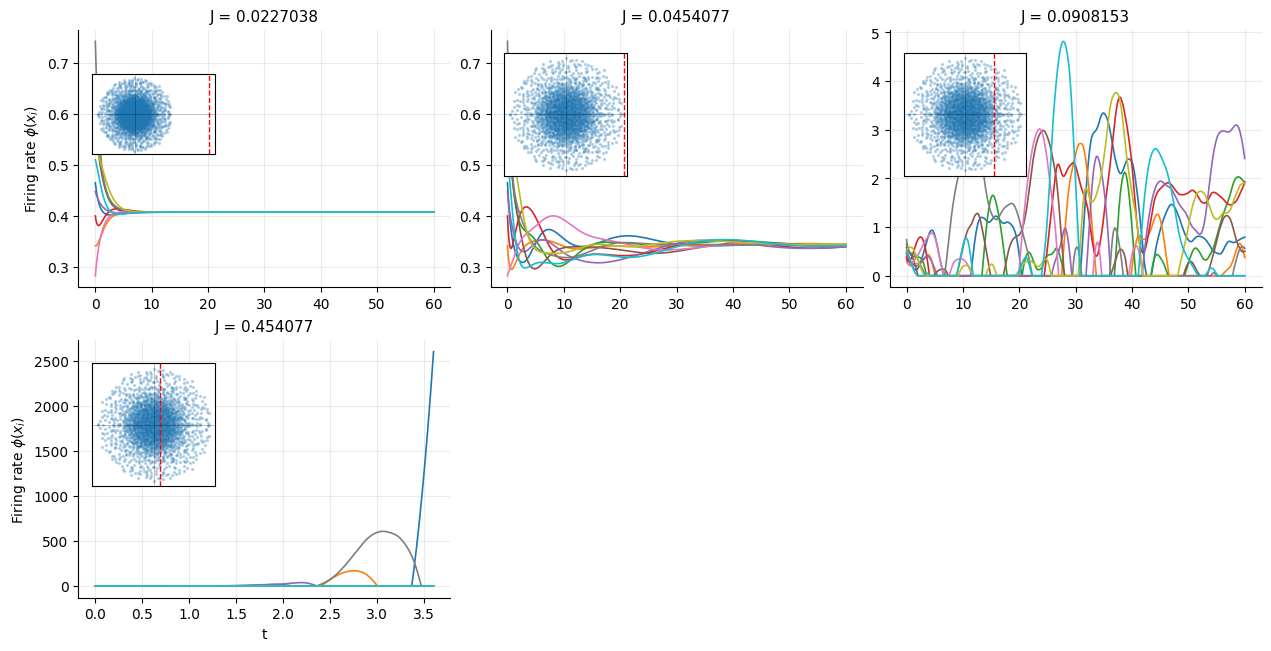

In [4]:
def main():
    # 1) parameters
    params = EIParams(
        N=2000,
        C=100,
        f=0.8,
        g=4.5,
        allow_autapses=False,

        gamma=0.5,
        phi_max=np.inf,
        #phi_max=2,

        I=0.0,
        dt=0.01,
        T=60.0,

        seed=0,
    )

    # 2) fix connectivity matrix
    W_base, meta = build_fixed_indegree_connectivity(params)
    print("Connectivity meta:", meta)

    J0 = solve_J0(params, J_lo=1e-4, J_hi=2.0)
    x0_at_J0 = fixed_point_x0(J0, params)
    CE = int(round(params.f * params.C))
    CI = params.C - CE
    R = np.sqrt(CE + (params.g ** 2) * CI)

    gain0 = phi_prime_scalar(x0_at_J0, params.gamma, params.phi_max)
    bulk_radius = gain0 * J0 * R

    print(f"J0 (predicted onset) = {J0:.6g}")
    print(f"x0(J0)              = {x0_at_J0:.6g}")
    print(f"phi'(x0(J0))         = {gain0:.6g}")
    print(f"bulk radius at J0    = {bulk_radius:.6g}")

    # 3) choose J value for different regimes
    Js = [0.5*J0, J0, 2*J0, 10*J0]

    fig = plot_fig1_like(
        W_base=W_base,
        Js=Js,
        p=params,
        n_trace=10,
        trace_seed=0,
        stop_if_rate_exceeds=2500.0,
        stability_re_line=1.0,
    )
    plt.show()

if __name__ == "__main__":
    main()